# Federated Learning Sensitivity Analysis with Knowledge Distillation

This notebook presents a comprehensive analysis of **Federated Learning (FL)** under varying client configurations, with a focus on **client count sensitivity** and **data heterogeneity (IID vs non-IID)** for a multi-label classification task.

In addition to standard FL baselines, we introduce and evaluate **Knowledge Distillation (KD)** strategies designed to improve robustness under non-IID settings.

### Core Components

- **Federated Training**  
  Clients train models locally and synchronize via weighted aggregation (FedAvg). Variants such as **FedProx** are included to mitigate client drift.

- **Client Sensitivity Analysis**  
  We systematically vary the number of clients (e.g., 2 → 10+) to study how increasing data fragmentation impacts performance under:
  - IID splits
  - Non-IID splits (label skew + size imbalance)

- **Knowledge Distillation (KD) Methods**
  - **Option 1 (Local KD / Drift Control):**  
    Each client distills knowledge from a frozen copy of the global model during local training.
  - **Option 3 (Local Teacher → Global Student):**  
    Each client maintains a stronger local teacher model and distills its knowledge into a shared global student.

- **Evaluation Metrics**  
  Models are evaluated using:
  - Macro / Micro F1-score
  - AUC and PR-AUC
  - Loss and prediction statistics

### Goal

The objective is to understand how **federated optimization behaves under increasing client fragmentation and heterogeneity**, and whether **knowledge distillation can improve stability and generalization** in these settings.

---

## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config
import itertools

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [52]:
# Base output directory for this notebook
KD_HISTORY_DIR = os.path.join("..", "History", "KD")

# Create directory if it doesn't exist
os.makedirs(KD_HISTORY_DIR, exist_ok=True)

print(f"Saving KD results to: {KD_HISTORY_DIR}")

Saving KD results to: ..\History\KD


## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [2]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [3]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [4]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [5]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [6]:
# FedAvg - working with parameter dictionary rather than deepcopy

def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.

    Args:
        global_model (dict): Global model parameter dictionary (in-place update).
        client_state_dicts (list[dict]): List of parameter dictionaries from clients.

    Returns:
        dict: Updated global parameter dictionary (averaged across clients).
    """
    for key in global_model.keys():
        # Stack corresponding parameters from all clients and take mean
        stacked = torch.stack(
            [client_dict[key].float() for client_dict in client_state_dicts],
            dim=0
        )
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [7]:
# --- FedProx and SCAFFOLD Aggregation Methods ---

def FedProx(global_model_dict, client_state_dicts, mu=0.01):
    """
    FedProx aggregation (same averaging as FedAvg, 
    since proximal regularization happens in local training).
    
    Args:
        global_model_dict (dict): Global model parameters.
        client_state_dicts (list[dict]): List of client parameter dicts.
        mu (float): Proximal term weight (applied during local updates).
    """
    # FedProx uses FedAvg-style aggregation; proximal term affects client training only.
    return FedAvg(global_model_dict, client_state_dicts)


def Scaffold(global_model_dict, client_state_dicts, c_global, c_clients, lr, num_clients):
    """
    SCAFFOLD server update rule:
        w_{t+1} = w_t + (1/K) * Σ [Δw_k - lr * (c_k - c)]
    
    Args:
        global_model_dict: current global weights (dict of tensors)
        client_state_dicts: list of client state_dicts after local updates
        c_global: global control variate dict
        c_clients: list of local control variate dicts
        lr: learning rate
        num_clients: number of clients participating this round
    
    Returns:
        Updated (global_model_dict, c_global, c_clients)
    """
    new_global = copy.deepcopy(global_model_dict)

    # Average model deltas with control variate correction
    for key in global_model_dict.keys():
        # Δw_k = w_k - w_global
        deltas = torch.stack(
            [client_state_dicts[k][key] - global_model_dict[key] for k in range(num_clients)],
            dim=0
        )
        mean_delta = torch.mean(deltas, dim=0)

        # correction term from c_k - c
        correction = torch.stack(
            [c_clients[k][key] - c_global[key] for k in range(num_clients)],
            dim=0
        ).mean(dim=0)

        # apply update
        new_global[key] = global_model_dict[key] + mean_delta - lr * correction

    # update global control variate
    for key in c_global.keys():
        delta_cs = torch.stack(
            [c_clients[k][key] - c_global[key] for k in range(num_clients)],
            dim=0
        )
        c_global[key] = c_global[key] + (1 / num_clients) * delta_cs.mean(dim=0)

    return new_global, c_global, c_clients


### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [8]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [9]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [10]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    mu: float = 0.01,                   # FedProx proximal coefficient
    global_params: dict = None,         # for FedProx / SCAFFOLD
    c_global: dict = None,              # for SCAFFOLD
    c_local: dict = None,               # for SCAFFOLD
    algorithm: str = "FedAvg"           # which algorithm is being used
) -> tuple[float, dict, dict]:
    """
    Perform local training for a single client.
    Supports FedAvg, FedProx, and SCAFFOLD.
    Returns (final_loss, updated_model_state, updated_c_local)
    """
    model.to(device)
    model.train()

    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Training loop ---
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            # --- FedProx proximal term ---
            if algorithm == "FedProx" and global_params is not None:
                prox_term = 0.0
                for w, w_global in zip(model.parameters(), global_params.values()):
                    prox_term += (w - w_global.to(device)).norm(2) ** 2
                loss += (mu / 2) * prox_term

            optimizer.zero_grad()
            loss.backward()

            # --- SCAFFOLD correction ---
            if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
                with torch.no_grad():
                    for w, cg, cl in zip(model.parameters(), c_global.values(), c_local.values()):
                        if w.grad is not None:
                            w.grad -= (cg.to(device) - cl.to(device))

            optimizer.step()

    return loss.item(), model.state_dict(), c_local


## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


### Set up

In [11]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,             # default (overridden per experiment)
    "rounds": 10,            # communication rounds per experiment
    "use_focal": False,      
    "gamma": 2.5,            # focal loss focusing parameter
    "mu": 0.01,              # FedProx proximal term coefficient
    "algorithm": "FedAvg"    # will be updated in loop to FedAvg, FedProx, or SCAFFOLD
}

# Path to pretrained embedding table
model_param_path = os.path.join("..", "Model", "processed_full.w2v")

In [12]:
# Load full training dataset (clients will be split dynamically later)
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

print(f"Loaded full training dataset: {len(train_dataset)} samples.")

val_loader = load_data("val")
test_loader = load_data("test")

Loaded full training dataset: 6453 samples.


### Eval stuff

In [13]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one 
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [14]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [15]:

def _fmt(x):
    """Safely format floats that might be None or NaN."""
    if x is None:
        return "n/a"
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return "n/a"
    return f"{x:.4f}"

@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None
):
    model.eval()
    model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    sigmoid_vals = torch.sigmoid(all_pred_raw)
    if per_label_thr is not None:
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        best_f1, best_thr = None, "per-label"
    else:
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    pr_macro = metrics.get("pr_auc_macro")
    pr_micro = metrics.get("pr_auc_micro")
    auc_macro = metrics.get("auc_macro")
    auc_micro = metrics.get("auc_micro")

    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    print(
        f"[Eval] Avg loss={_fmt(avg_loss)} | "
        f"F1_micro={_fmt(metrics.get('f1_micro'))} | F1_macro={_fmt(metrics.get('f1_macro'))} | "
        f"AUC_macro={_fmt(auc_macro)} | AUC_micro={_fmt(auc_micro)} | "
        f"PR-AUC_macro={_fmt(pr_macro)} | PR-AUC_micro={_fmt(pr_micro)} | "
        f"Best_F1={_fmt(best_f1 if best_f1 is not None else metrics.get('f1_micro'))} @ thr={best_thr} | "
        f"Avg labels/sample={avg_pred_labels:.2f}"
    )

    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr
    return avg_loss, metrics


## Client Number Sensitivity Analysis

Goal: test how FL performance changes as the number of simulated clients increases.

**Option A (implemented now): IID split**
- Randomly split the same training dataset into K approximately equal partitions.

**Option B (later): non-IID split**
- Split data to mimic hospital heterogeneity (label prevalence shifts, size imbalance, etc.).

We keep everything else fixed (model, optimizer, rounds, local epochs) so the only change is
the number of clients and the resulting partitioning.

In [16]:
# do weighted by partition size instead of mean by clients (important for different sizes like part b)

def FedAvg_weighted(client_state_dicts: list[dict], client_sizes: list[int]) -> dict:
    """
    Weighted FedAvg by client dataset size. Returns a NEW state_dict (does not mutate inputs).
    client_state_dicts: list of state_dicts (as produced by model.state_dict())
    client_sizes: list of ints (number of samples per client)
    """
    total = float(sum(client_sizes))
    out = {}
    # iterate keys from first client's state_dict
    for key in client_state_dicts[0].keys():
        # accumulate weighted sum
        acc = None
        for sd, n in zip(client_state_dicts, client_sizes):
            term = sd[key].float() * (n / total)
            acc = term if acc is None else acc + term
        out[key] = acc
    return out

### IID Split

In [17]:
# IID split helper for option A

def split_dataset_iid(dataset, num_clients: int, seed: int = 42):
    """
    IID split: shuffle indices and split into K chunks.
    Returns list of Subset datasets.
    """
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    # chunk sizes (nearly equal)
    base = len(dataset) // num_clients
    rem  = len(dataset) % num_clients
    sizes = [base + (1 if i < rem else 0) for i in range(num_clients)]

    subsets = []
    start = 0
    for sz in sizes:
        subsets.append(Subset(dataset, indices[start:start+sz].tolist()))
        start += sz
    return subsets

### Non-IID Split (Option B)

Multi-label non-IID split that simulates:
- size imbalance across hospitals (Dirichlet)
- per-hospital label-prevalence shifts (preferred labels + bias)

Parameters:
- size_alpha: smaller -> more size imbalance
- labels_per_client: how many "specialty" labels each client prefers
- bias_strength: probability of sampling examples that contain preferred labels

In [18]:
# Non-IID splitter for multi-label datasets

def split_dataset_noniid_multilabel(
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,          # Dirichlet parameter for client sizes
    labels_per_client: int = 10,      # number of preferred labels per client
    bias_strength: float = 0.85       # prob of sampling from preferred-label examples
):
    """
    Splits `dataset` (TensorDataset or similar with Y in dataset.tensors[1])
    into `num_clients` Subset objects with non-IID label prevalence and size imbalance.
    """
    rng = np.random.default_rng(seed)

    # extract Y matrix
    if hasattr(dataset, "tensors"):
        Y = dataset.tensors[1].cpu()
    else:
        # fallback for generic dataset: collect Y
        Y = torch.stack([dataset[i][1] for i in range(len(dataset))]).cpu()

    n = len(dataset)
    n_labels = Y.shape[1]

    # --- sizes via Dirichlet ---
    props = rng.dirichlet(alpha=np.ones(num_clients) * size_alpha)
    sizes = (props * n).astype(int)
    diff = n - sizes.sum()
    for i in range(abs(diff)):
        sizes[i % num_clients] += 1 if diff > 0 else -1
    sizes = sizes.tolist()

    # --- label -> indices map ---
    label_to_indices = defaultdict(list)
    for idx in range(n):
        labs = torch.nonzero(Y[idx]).flatten().tolist()
        for lab in labs:
            label_to_indices[lab].append(idx)

    # --- preferred labels per client ---
    all_labels = np.arange(n_labels)
    preferred = []
    for _ in range(num_clients):
        preferred.append(rng.choice(all_labels, size=min(labels_per_client, n_labels), replace=False).tolist())

    # --- assignment ---
    unassigned = set(range(n))
    client_indices = [[] for _ in range(num_clients)]

    def pick_preferred(client_id):
        labs = preferred[client_id]
        candidates = []
        for lab in labs:
            candidates.extend(label_to_indices.get(lab, []))
        if not candidates:
            return None
        rng.shuffle(candidates)
        for idx in candidates:
            if idx in unassigned:
                return idx
        return None

    # fill clients
    for cid in range(num_clients):
        target = sizes[cid]
        while len(client_indices[cid]) < target and unassigned:
            use_pref = rng.random() < bias_strength
            idx = pick_preferred(cid) if use_pref else None

            if idx is None:
                # choose uniformly from remaining
                idx = rng.choice(list(unassigned))

            client_indices[cid].append(int(idx))
            unassigned.remove(int(idx))

    # distribute any leftovers
    if unassigned:
        leftovers = list(unassigned)
        rng.shuffle(leftovers)
        for i, idx in enumerate(leftovers):
            client_indices[i % num_clients].append(int(idx))

    # build subsets
    subsets = [Subset(dataset, inds) for inds in client_indices]
    return subsets

### Targeted Sensitivity Analysis

In [19]:
def run_fl_sensitivity_once(
    split_mode: str,            # "iid" or "noniid"
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    algo: str = "FedAvg",        # "FedAvg" or "FedProx"
    mu: float = 0.01,            # only used for FedProx
    # non-IID params
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85
):
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(train_dataset, num_clients=num_clients, seed=seed)
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [DataLoader(cd, batch_size=config["batch_size"], shuffle=True) for cd in client_datasets]

    # --- init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    client_model = copy.deepcopy(global_model)

    # --- FL rounds ---
    for rnd in tqdm(range(config["rounds"]), colour="blue",
                    desc=f"{algo} {split_mode} | K={num_clients} | E={local_epochs}"):
        client_params = []
        for loader in client_loaders:
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, _ = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=mu,
                global_params=(global_model.state_dict() if algo == "FedProx" else None),
                c_global=None,
                c_local=None,
                algorithm=algo,
            )
            client_params.append(client_state)

        # server aggregation: sample-size weighted FedAvg (safe for IID + nonIID)
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

In [20]:
# # =========================
# # Sensitivity Sweep (FULL)
# # =========================

# client_counts = [2, 3, 5, 8, 10]      # 2–20 as requested

# # keep fast first; later bump rounds to your real value
# sweep_config = config.copy()
# sweep_config["rounds"] = 10  # debug; set higher later

# # choose non-IID severity (keep fixed across all methods)
# noniid_params = dict(size_alpha=0.5, labels_per_client=10, bias_strength=0.85)

# # methods to compare
# METHODS = [
#     #dict(method="FedAvg",  algo="FedAvg",  mu=None,  local_epochs=3)
#     dict(method="FedAvg_E1", algo="FedAvg", mu=None, local_epochs=1),

#     #dict(method="FedProx_mu0.01_E3", algo="FedProx", mu=0.01, local_epochs=3)
#     #dict(method="FedProx_mu0.1_E3",  algo="FedProx", mu=0.10, local_epochs=3)

#     dict(method="FedProx_mu0.01_E1", algo="FedProx", mu=0.01, local_epochs=1),
#     dict(method="FedProx_mu0.1_E1",  algo="FedProx", mu=0.10, local_epochs=1),

# ]

# out_path = "../History/sensitivity_all_methods.csv"

# all_rows = []
# for split_mode in ["iid", "noniid"]:
#     for m in METHODS:
#         for k in client_counts:
#             print(f"\n=== {split_mode.upper()} | {m['method']} | K={k} ===")

#             metrics, elapsed = run_fl_sensitivity_once(
#                 split_mode=split_mode,
#                 num_clients=k,
#                 local_epochs=m["local_epochs"],
#                 config=sweep_config,
#                 train_dataset=train_dataset,
#                 val_loader=val_loader,
#                 test_loader=test_loader,
#                 device=device,
#                 seed=42,
#                 algo=m["algo"],
#                 mu=(m["mu"] if m["mu"] is not None else 0.0),
#                 **(noniid_params if split_mode == "noniid" else {})
#             )

#             row = dict(
#                 split=split_mode,
#                 method=m["method"],
#                 algo=m["algo"],
#                 mu=m["mu"],
#                 local_epochs=m["local_epochs"],
#                 clients=k,
#                 auc_macro=metrics.get("auc_macro"),
#                 auc_micro=metrics.get("auc_micro"),
#                 f1_macro=metrics.get("f1_macro"),
#                 f1_micro=metrics.get("f1_micro"),
#                 pr_auc_macro=metrics.get("pr_auc_macro"),
#                 pr_auc_micro=metrics.get("pr_auc_micro"),
#                 time_sec=elapsed,
#             )
#             if split_mode == "noniid":
#                 row.update(noniid_params)

#             all_rows.append(row)

#             pd.DataFrame(all_rows).to_csv(out_path, index=False)

# print(f"\nDone. Saved to {out_path}")
# sens_all = pd.DataFrame(all_rows)
# display(sens_all)

In [21]:
# # Load + table (primary metrics)

# out_path = "../History/sensitivity_all_methods.csv"
# sens_all = pd.read_csv(out_path)
# print("Loaded:", out_path, "rows=", len(sens_all))

# # Comparison table: primary metrics (Macro F1, PR-AUC Macro)
# table = sens_all[["split","method","clients","f1_macro","pr_auc_macro","time_sec"]].copy()
# display(table.head())

In [22]:
# # Plotting

# # Pre-define visually distinct markers/linestyles (works for both color and B/W)
# MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
# LINESTYLES = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,5)), (0,(1,1))]

# def plot_macro_f1_all_methods(df, split_mode: str, bw: bool = False):
#     d = df[df["split"] == split_mode].copy()

#     # consistent order in legend (so runs are stable)
#     methods = sorted(d["method"].unique())

#     plt.figure(figsize=(10, 5))

#     # cycle marker/style pairs so each method is distinguishable
#     style_cycle = itertools.cycle([
#         (m, ls) for m in MARKERS for ls in LINESTYLES
#     ])

#     for method in methods:
#         g = d[d["method"] == method].sort_values("clients")
#         marker, ls = next(style_cycle)

#         if bw:
#             plt.plot(
#                 g["clients"], g["f1_macro"],
#                 color="black",
#                 linestyle=ls,
#                 marker=marker,
#                 markersize=6,
#                 linewidth=2,
#                 label=method
#             )
#         else:
#             plt.plot(
#                 g["clients"], g["f1_macro"],
#                 linestyle=ls,
#                 marker=marker,
#                 markersize=6,
#                 linewidth=2,
#                 label=method
#             )

#     plt.xlabel("Number of Clients")
#     plt.ylabel("Macro F1")
#     plt.title(f"Macro F1 vs #Clients ({split_mode.upper()})")
#     plt.grid(True, alpha=0.3)
#     plt.legend(fontsize=8, ncols=2, frameon=True)
#     plt.tight_layout()
#     plt.show()

# # Color
# plot_macro_f1_all_methods(sens_all, "iid", bw=False)
# plot_macro_f1_all_methods(sens_all, "noniid", bw=False)

# # Black & White
# plot_macro_f1_all_methods(sens_all, "iid", bw=True)
# plot_macro_f1_all_methods(sens_all, "noniid", bw=True)

## Knowledge Distillation Extensions (Option 1 and Option 3)

This section adds two KD-based federated training variants for the multi-label ICD task:

**Option 1 — Local KD / Drift Control**
- Each client receives the current global model.
- A frozen copy acts as the **teacher**.
- A trainable copy acts as the **student**.
- The student is trained on:
  - supervised BCE loss on ground-truth labels
  - KD loss against the frozen global teacher

**Option 3 — Local Heterogeneous Teacher → Global Student**
- The server maintains a shared global **student** model.
- Each client maintains its own persistent local **teacher**.
- The teacher is trained locally on hard labels.
- The student is trained on:
  - supervised BCE loss
  - KD loss against the local teacher

Notes:
- These implementations are designed for **multi-label** prediction.
- Server-side distillation is supported as an optional post-aggregation refinement step.
- FedProx compatibility is included by applying the proximal penalty to the uploaded student model.
- In this notebook, server distillation follows the toy reference and uses client mini-batches
  as the distillation input source. For a stricter privacy setup, this can later be replaced
  with a proxy/public dataset without changing the client-side KD code.

In [23]:
# Suggested teacher pool:
# - "medium" teacher: modest capacity increase over student
# - "mullenbach" teacher: closer to stronger CAML-style settings
# - "wide" teacher: even larger local teacher
#
# You can adjust these later, but this is a good first pool. 
# We may have to track things like overfitting for the larger mdoels later

option3_teacher_pool = [
    {"name": "t1_light",     "num_of_filters": 28, "kernel_size": 4,  "drop_out": 0.2},
    {"name": "t2_medium",    "num_of_filters": 36, "kernel_size": 6,  "drop_out": 0.2},
    {"name": "t3_caml_ref",  "num_of_filters": 50, "kernel_size": 10, "drop_out": 0.2},  # Mullenbach
    {"name": "t4_large",     "num_of_filters": 64, "kernel_size": 10, "drop_out": 0.2},
    {"name": "t5_xlarge",    "num_of_filters": 80, "kernel_size": 12, "drop_out": 0.2},
]

# KD configuration defaults (can be adjusted later)

kd_config = {
    "kd_alpha": 0.5,             # weight on supervised loss
    "kd_temperature": 2.0,       # temperature for KD

    # Option 3 teacher-pool config
    "teacher_pool": option3_teacher_pool,
    "teacher_assignment": "round_robin",
    "teacher_steps_per_batch": 1,

    # Server distillation config
    "server_distill_steps": 10,   # number of server KD refinement steps after aggregation
    "server_distill_lr": 0.002,   # optimizer LR for server KD phase
}

### KD Loss Utilities

For this ICD setting, the task is **multi-label**, so we do not use softmax distillation.
Instead, we match temperature-scaled sigmoid outputs label-wise.

In [24]:
def build_supervised_loss(
    train_loader,
    n_labels,
    use_focal: bool = False,
    gamma: float = 2.5,
    device: str = "cpu"
):
    """
    Build the supervised loss used for a client's local dataset.
    """
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        return FocalLoss(alpha=alpha, gamma=gamma)
    else:
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def multilabel_kd_loss(student_logits, teacher_logits, temperature: float = 2.0):
    """
    Multi-label KD loss using temperature-scaled sigmoid probabilities.

    This behaves like a binary KL-style matching loss across labels.
    """
    T = temperature

    teacher_probs = torch.sigmoid(teacher_logits / T)
    student_probs = torch.sigmoid(student_logits / T)

    kd = F.binary_cross_entropy(
        student_probs,
        teacher_probs,
        reduction="mean"
    )

    return kd * (T * T)

In [25]:
# Helpers for FedDKD

# Helper to rebuild client models from uploaded state dicts
def build_student_model_from_state(
    state_dict: dict,
    table_path: str,
    config: dict,
    device: str = "cpu"
):
    """
    Rebuild a student/global-compatible model from a state_dict.
    Used so the server can treat returned client students/models as teachers
    during the server distillation phase.
    """
    model = GenerateModel(
        table_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model

# Multi-label server distillation engine
def execute_server_distillation(
    global_model: nn.Module,
    client_teacher_models: list[nn.Module],
    client_loaders: list[DataLoader],
    client_sizes: list[int],
    kd_temperature: float = 2.0,
    distill_steps: int = 10,
    distill_lr: float = 0.002,
    device: str = "cpu"
):
    """
    Post-aggregation server distillation phase.

    Procedure:
    1. Global model is already initialized from weighted FedAvg.
    2. Each returned client model/student acts as a teacher.
    3. For each server KD step, the server pulls one batch from each client's loader.
    4. The global model is optimized to match each teacher on that client's batch.

    Important:
    - This mirrors the toy notebook's pattern and is NOT privacy-clean for deployment.
    - For stricter settings, replace client_loaders with a proxy/public distillation loader.
    """
    global_model.train()
    optimizer = torch.optim.Adam(global_model.parameters(), lr=distill_lr, betas=(0.9, 0.99))

    total_size = float(sum(client_sizes))
    client_weights = [sz / total_size for sz in client_sizes]

    client_iters = [iter(loader) for loader in client_loaders]

    for teacher in client_teacher_models:
        teacher.eval()

    for _ in range(distill_steps):
        optimizer.zero_grad()
        total_loss = 0.0

        for cid, teacher in enumerate(client_teacher_models):
            try:
                X_batch, _ = next(client_iters[cid])
            except StopIteration:
                client_iters[cid] = iter(client_loaders[cid])
                X_batch, _ = next(client_iters[cid])

            X_batch = X_batch.to(device)

            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            student_logits, _ = global_model(X_batch)

            kd_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            weighted_loss = client_weights[cid] * kd_loss
            weighted_loss.backward()
            total_loss += weighted_loss.item()

        optimizer.step()

    return global_model

### Proximal Regularization Helper

Used when combining Option 1 or Option 3 with FedProx.
The proximal penalty is applied only to the uploaded student model.

In [26]:
def proximal_term(model: nn.Module, global_params: dict, device: str = "cpu"):
    """
    Compute FedProx proximal penalty relative to the received global model.
    """
    prox = 0.0
    for name, param in model.named_parameters():
        prox += torch.norm(param - global_params[name].to(device), p=2) ** 2
    return prox

### Option 1 — Local KD / Drift Control

Teacher: frozen copy of the global model  
Student: trainable local copy initialized from the same global model

In [27]:
def client_update_option1(
    global_model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01
):
    """
    Option 1:
    - teacher = frozen global model
    - student = local trainable model
    - local loss = supervised + KD (+ optional FedProx penalty)
    """
    teacher = copy.deepcopy(global_model).to(device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    student = copy.deepcopy(global_model).to(device)
    student.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_model.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    optimizer = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            student_logits, _ = student(X_batch)
            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            optimizer.step()

            last_loss = loss.item()

    return last_loss, student.state_dict()

### Option 3 — Local Heterogeneous Teacher Pool -> Global Student

Teacher: persistent local client model drawn from a heterogeneous CAML-style teacher pool  
Student: shared global model copied locally each round

Instead of assigning every client the same larger teacher, we assign each client
a persistent teacher profile from a pool of five ConvAttnPool variants. The pool
is centered around a CAML reference configuration inspired by Mullenbach et al.,
with both smaller and larger capacity variants included.

This keeps the student architecture homogeneous for aggregation while making the
local teachers more meaningfully heterogeneous in capacity and receptive field.

In [28]:
def build_teacher_from_profile(table_path: str, profile: dict) -> ConvAttnPool:
    """
    Build a local Option 3 teacher from a teacher profile dictionary.
    """
    return ConvAttnPool(
        table_path=table_path,
        label_space=50,
        num_of_filters=profile["num_of_filters"],
        kernel_size=profile["kernel_size"],
        drop_out=profile.get("drop_out", 0.2)
    )

def initialize_option3_teachers(
    num_clients: int,
    table_path: str,
    teacher_pool: list[dict],
    assignment: str = "round_robin",
    seed: int = 42,
    device: str = "cpu"
):
    """
    Create one persistent local teacher per client from a heterogeneous teacher pool.

    Returns:
        teachers: list of nn.Module
        teacher_profiles: list of dicts describing the assigned profile for each client
    """
    if len(teacher_pool) == 0:
        raise ValueError("teacher_pool must contain at least one teacher profile")

    rng = np.random.default_rng(seed)

    if assignment == "round_robin":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[i % len(teacher_pool)])
            for i in range(num_clients)
        ]
    elif assignment == "random":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[rng.integers(0, len(teacher_pool))])
            for _ in range(num_clients)
        ]
    else:
        raise ValueError("assignment must be 'round_robin' or 'random'")

    teachers = []
    for profile in teacher_profiles:
        teacher = build_teacher_from_profile(table_path, profile).to(device)
        teachers.append(teacher)

    return teachers, teacher_profiles

In [29]:
def client_update_option3(
    global_student: nn.Module,
    local_teacher: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01,
    teacher_steps_per_batch: int = 1
):
    """
    Option 3:
    - local teacher persists on client
    - teacher trains on hard labels
    - student trains on supervised + KD from teacher
    - only student weights are uploaded
    - optional FedProx penalty is applied to the student only

    teacher_steps_per_batch:
        number of teacher optimization steps before one student update.
        keep at 1 initially.
    """
    student = copy.deepcopy(global_student).to(device)
    teacher = local_teacher.to(device)

    student.train()
    teacher.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_student.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    student_opt = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))
    teacher_opt = torch.optim.Adam(teacher.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # ---- Teacher update on hard labels ----
            for _ts in range(teacher_steps_per_batch):
                teacher_opt.zero_grad()
                teacher_logits, _ = teacher(X_batch)
                teacher_loss = sup_loss_fn(teacher_logits, y_batch)
                teacher_loss.backward()
                teacher_opt.step()

            # ---- Student update on hard labels + teacher KD ----
            student_opt.zero_grad()
            student_logits, _ = student(X_batch)

            with torch.no_grad():
                teacher_logits_detached, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits_detached,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            student_opt.step()

            last_loss = loss.item()

    return last_loss, student.state_dict(), teacher

### KD-Capable Federated Runner

This runner supports:
- baseline FedAvg / FedProx
- Option 1
- Option 3

Server distillation is not included yet.

In [30]:
def run_fl_kd_once(
    split_mode: str,             # "iid" or "noniid"
    num_clients: int,
    local_epochs: int,
    config: dict,
    kd_config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    method: str = "baseline",    # "baseline", "option1", "option3"
    base_algo: str = "FedAvg",   # "FedAvg" or "FedProx"
    mu: float = 0.01,
    server_distill: bool = False,
    # non-IID params
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85
):
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(train_dataset, num_clients=num_clients, seed=seed)
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- global shared model / student ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    # --- persistent teachers for Option 3 ---
    local_teachers = None
    teacher_profiles = None
    if method == "option3":
        local_teachers, teacher_profiles = initialize_option3_teachers(
            num_clients=num_clients,
            table_path=model_param_path,
            teacher_pool=kd_config["teacher_pool"],
            assignment=kd_config.get("teacher_assignment", "round_robin"),
            seed=seed,
            device=device
        )

    # --- rounds ---
    for rnd in tqdm(
        range(config["rounds"]),
        colour="blue",
        desc=(
            f"{method} | {base_algo}"
            f"{' + SD' if server_distill else ''} | {split_mode} | K={num_clients} | E={local_epochs}"
        )
    ):
        client_params = []
        client_teacher_models = []

        for cid, loader in enumerate(client_loaders):
            if method == "baseline":
                client_model = copy.deepcopy(global_model)

                _, client_state, _ = client_update(
                    model=client_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    mu=mu,
                    global_params=(global_model.state_dict() if base_algo == "FedProx" else None),
                    c_global=None,
                    c_local=None,
                    algorithm=base_algo
                )
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option1":
                _, client_state = client_update_option1(
                    global_model=global_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu
                )
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option3":
                _, client_state, updated_teacher = client_update_option3(
                    global_student=global_model,
                    local_teacher=local_teachers[cid],
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu,
                    teacher_steps_per_batch=kd_config.get("teacher_steps_per_batch", 1)
                )
                local_teachers[cid] = updated_teacher
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            else:
                raise ValueError("method must be one of: baseline, option1, option3")

        # --- first do standard weighted aggregation ---
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

        # --- optional server distillation refinement ---
        if server_distill:
            global_model = execute_server_distillation(
                global_model=global_model,
                client_teacher_models=client_teacher_models,
                client_loaders=client_loaders,
                client_sizes=client_sizes,
                kd_temperature=kd_config["kd_temperature"],
                distill_steps=kd_config.get("server_distill_steps", 10),
                distill_lr=kd_config.get("server_distill_lr", config["lr"]),
                device=device
            )

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time

    # optional logging fields for bookkeeping
    metrics["server_distill"] = bool(server_distill)
    metrics["method"] = method
    metrics["base_algo"] = base_algo
    if method == "option3" and teacher_profiles is not None:
        metrics["teacher_profiles"] = [tp["name"] for tp in teacher_profiles]

    return metrics, elapsed

### Quick KD + FedProx Smoke Tests

Run a small sanity check on the current method set before launching the full sweep.

Current methods:
- Baseline FedAvg
- Baseline FedProx (mu = 0.01)
- Option 1 + FedAvg
- Option 1 + FedAvg + Server Distillation
- Option 1 + FedProx (mu = 0.01)
- Option 1 + FedProx + Server Distillation
- Option 3 + FedAvg
- Option 3 + FedAvg + Server Distillation
- Option 3 + FedProx (mu = 0.01)
- Option 3 + FedProx + Server Distillation

Setup:
- non-IID split
- 2 clients
- 1 local epoch
- fixed non-IID severity

In [31]:
# %%
def clean_metrics(metrics: dict):
    out = {}
    for k, v in metrics.items():
        if isinstance(v, (np.floating, float)):
            out[k] = float(v)
        else:
            out[k] = v
    return out


def print_metrics(title: str, metrics: dict, time_sec: float):
    m = clean_metrics(metrics)

    print(f"\n=== {title} ===")
    print(f"Time          : {time_sec:.2f}s")
    print(f"F1 Macro      : {m.get('f1_macro', float('nan')):.4f}")
    print(f"F1 Micro      : {m.get('f1_micro', float('nan')):.4f}")
    print(f"AUC Macro     : {m.get('auc_macro', float('nan')):.4f}")
    print(f"AUC Micro     : {m.get('auc_micro', float('nan')):.4f}")
    print(f"PR-AUC Macro  : {m.get('pr_auc_macro', float('nan')):.4f}")
    print(f"PR-AUC Micro  : {m.get('pr_auc_micro', float('nan')):.4f}")


def compare_methods(results: dict):
    rows = []
    for name, (metrics, time_sec) in results.items():
        m = clean_metrics(metrics)
        rows.append({
            "method": name,
            "f1_macro": m.get("f1_macro"),
            "f1_micro": m.get("f1_micro"),
            "pr_auc_macro": m.get("pr_auc_macro"),
            "pr_auc_micro": m.get("pr_auc_micro"),
            "auc_macro": m.get("auc_macro"),
            "auc_micro": m.get("auc_micro"),
            "time_sec": round(time_sec, 2)
        })

    df = pd.DataFrame(rows).sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    ).reset_index(drop=True)

    display(df)
    return df

In [32]:
# Shared smoke-test settings

smoke_kwargs = dict(
    split_mode="noniid",
    num_clients=2,
    local_epochs=1,
    config=config,
    kd_config=kd_config,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    seed=42,
    mu=0.01,
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

In [33]:
# # 1) Baseline FedAvg

# smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg = run_fl_kd_once(
#     method="baseline",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Baseline FedAvg", smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg)

In [34]:
# # 2) Baseline FedProx

# smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox = run_fl_kd_once(
#     method="baseline",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Baseline FedProx (mu=0.01)", smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox)

In [35]:
# # 3) Option 1 + FedAvg

# smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg = run_fl_kd_once(
#     method="option1",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedAvg", smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg)

In [36]:
# # 4) Option 1 + FedAvg + FedDKD

# smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd = run_fl_kd_once(
#     method="option1",
#     base_algo="FedAvg",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedAvg + Server Distill", smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd)

In [37]:
# # 5) Option 1 + FedProx

# smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox = run_fl_kd_once(
#     method="option1",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedProx (mu=0.01)", smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox)

In [38]:
# # 6) Option 1 + FedProx + FedDKD

# smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd = run_fl_kd_once(
#     method="option1",
#     base_algo="FedProx",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 1 + FedProx + Server Distill (mu=0.01)", smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd)

In [39]:
# # 7) Option 3 + FedAvg

# smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedAvg", smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg)

In [40]:
# # 8) Option 3 + FedAvg + FedDKD

# smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedAvg + Server Distill", smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd)

In [41]:
# # 9) Option 3 + FedProx

# smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox = run_fl_kd_once(
#     method="option3",
#     base_algo="FedProx",
#     server_distill=False,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedProx (mu=0.01)", smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox)

In [42]:
# # 10) Option 3 + FedProx + FedDKD

# smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd = run_fl_kd_once(
#     method="option3",
#     base_algo="FedProx",
#     server_distill=True,
#     **smoke_kwargs
# )

# print_metrics("Option 3 + FedProx + Server Distill (mu=0.01)", smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd)

In [43]:
# # Combined comparison table

# smoke_df = compare_methods({
#     "Baseline_FedAvg": (smoke_metrics_baseline_fedavg, smoke_time_baseline_fedavg),
#     "Baseline_FedProx_mu0.01": (smoke_metrics_baseline_fedprox, smoke_time_baseline_fedprox),

#     "Opt1_FedAvg": (smoke_metrics_opt1_fedavg, smoke_time_opt1_fedavg),
#     "Opt1_FedAvg_SD": (smoke_metrics_opt1_fedavg_sd, smoke_time_opt1_fedavg_sd),
#     "Opt1_FedProx_mu0.01": (smoke_metrics_opt1_fedprox, smoke_time_opt1_fedprox),
#     "Opt1_FedProx_mu0.01_SD": (smoke_metrics_opt1_fedprox_sd, smoke_time_opt1_fedprox_sd),

#     "Opt3_FedAvg": (smoke_metrics_opt3_fedavg, smoke_time_opt3_fedavg),
#     "Opt3_FedAvg_SD": (smoke_metrics_opt3_fedavg_sd, smoke_time_opt3_fedavg_sd),
#     "Opt3_FedProx_mu0.01": (smoke_metrics_opt3_fedprox, smoke_time_opt3_fedprox),
#     "Opt3_FedProx_mu0.01_SD": (smoke_metrics_opt3_fedprox_sd, smoke_time_opt3_fedprox_sd),
# })

## Actual Client Sweep for KD

In [ ]:
# This section runs the full experiment matrix across client counts and split types.
# Results are saved incrementally to CSV and can be plotted afterward.

client_counts = [2, 3, 5, 8, 10]

sweep_config = config.copy()
sweep_config["rounds"] = 10   # keep or change as needed

noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

KD_METHODS = [
    dict(method_name="Baseline_FedAvg",            method="baseline", base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Baseline_FedProx_mu0.01",    method="baseline", base_algo="FedProx", mu=0.01, server_distill=False),

    dict(method_name="Opt1_FedAvg",                method="option1",  base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Opt1_FedAvg_SD",             method="option1",  base_algo="FedAvg",  mu=0.0,  server_distill=True),
    dict(method_name="Opt1_FedProx_mu0.01",        method="option1",  base_algo="FedProx", mu=0.01, server_distill=False),
    dict(method_name="Opt1_FedProx_mu0.01_SD",     method="option1",  base_algo="FedProx", mu=0.01, server_distill=True),

    dict(method_name="Opt3_FedAvg",                method="option3",  base_algo="FedAvg",  mu=0.0,  server_distill=False),
    dict(method_name="Opt3_FedAvg_SD",             method="option3",  base_algo="FedAvg",  mu=0.0,  server_distill=True),
    dict(method_name="Opt3_FedProx_mu0.01",        method="option3",  base_algo="FedProx", mu=0.01, server_distill=False),
    dict(method_name="Opt3_FedProx_mu0.01_SD",     method="option3",  base_algo="FedProx", mu=0.01, server_distill=True),
]

# out_path = "../History/kd_client_sweep_results_r10_e1.csv"
out_path = os.path.join(KD_HISTORY_DIR, "kd_client_sweep_results_r10_e1.csv")

In [45]:
# %%
# Sweep runner with resume / skip-completed support

if os.path.exists(out_path):
    kd_sweep_df_existing = pd.read_csv(out_path)
    all_rows = kd_sweep_df_existing.to_dict(orient="records")
    completed_keys = set(
        zip(
            kd_sweep_df_existing["split"],
            kd_sweep_df_existing["method_name"],
            kd_sweep_df_existing["clients"]
        )
    )
    print(f"Found existing results at {out_path}")
    print(f"Loaded {len(kd_sweep_df_existing)} completed rows.")
else:
    all_rows = []
    completed_keys = set()
    print("No existing results found. Starting fresh.")

for split_mode in ["iid", "noniid"]:
    for m in KD_METHODS:
        for k in client_counts:
            run_key = (split_mode, m["method_name"], k)

            if run_key in completed_keys:
                print(f"Skipping completed run: {split_mode} | {m['method_name']} | K={k}")
                continue

            print(f"\n=== {split_mode.upper()} | {m['method_name']} | K={k} ===")

            try:
                metrics, elapsed = run_fl_kd_once(
                    split_mode=split_mode,
                    num_clients=k,
                    local_epochs=1,   # or 3 if you want the heavier final setting
                    config=sweep_config,
                    kd_config=kd_config,
                    train_dataset=train_dataset,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=device,
                    seed=42,
                    method=m["method"],
                    base_algo=m["base_algo"],
                    mu=m["mu"],
                    server_distill=m["server_distill"],
                    **(noniid_params if split_mode == "noniid" else {})
                )

                row = {
                    "split": split_mode,
                    "clients": k,

                    "method_name": m["method_name"],
                    "method": m["method"],
                    "base_algo": m["base_algo"],
                    "mu": m["mu"],
                    "server_distill": m["server_distill"],

                    "local_epochs": 1,
                    "rounds": sweep_config["rounds"],

                    "kd_alpha": kd_config["kd_alpha"],
                    "kd_temperature": kd_config["kd_temperature"],
                    "server_distill_steps": kd_config.get("server_distill_steps", None),
                    "server_distill_lr": kd_config.get("server_distill_lr", None),

                    "f1_macro": metrics.get("f1_macro"),
                    "f1_micro": metrics.get("f1_micro"),
                    "pr_auc_macro": metrics.get("pr_auc_macro"),
                    "pr_auc_micro": metrics.get("pr_auc_micro"),
                    "auc_macro": metrics.get("auc_macro"),
                    "auc_micro": metrics.get("auc_micro"),
                    "best_f1_micro": metrics.get("best_f1_micro"),
                    "best_thr": metrics.get("best_thr"),

                    "time_sec": elapsed,
                }

                if split_mode == "noniid":
                    row.update(noniid_params)

                all_rows.append(row)
                completed_keys.add(run_key)

                pd.DataFrame(all_rows).to_csv(out_path, index=False)
                print(f"Saved result to {out_path}")

            except Exception as e:
                print(f"FAILED: {split_mode} | {m['method_name']} | K={k}")
                print(f"Reason: {e}")

print(f"\nSweep finished. Results saved to: {out_path}")

kd_sweep_df = pd.DataFrame(all_rows)
display(kd_sweep_df.head())

No existing results found. Starting fresh.

=== IID | Baseline_FedAvg | K=2 ===


baseline | FedAvg | iid | K=2 | E=1: 100%|██████████| 10/10 [00:39<00:00,  3.92s/it]


[Per-Label Thresholds] Macro F1=0.4789
[Eval] Avg loss=0.5026 | F1_micro=0.4742 | F1_macro=0.4978 | AUC_macro=0.8250 | AUC_micro=0.8487 | PR-AUC_macro=0.4434 | PR-AUC_micro=0.4989 | Best_F1=0.4742 @ thr=per-label | Avg labels/sample=10.95
Saved result to ../History/kd_client_sweep_results_r10_e1.csv

=== IID | Baseline_FedAvg | K=3 ===


baseline | FedAvg | iid | K=3 | E=1: 100%|██████████| 10/10 [00:34<00:00,  3.41s/it]


[Per-Label Thresholds] Macro F1=0.4469
[Eval] Avg loss=0.5333 | F1_micro=0.4470 | F1_macro=0.4709 | AUC_macro=0.8069 | AUC_micro=0.8320 | PR-AUC_macro=0.4067 | PR-AUC_micro=0.4687 | Best_F1=0.4470 @ thr=per-label | Avg labels/sample=11.78
Saved result to ../History/kd_client_sweep_results_r10_e1.csv

=== IID | Baseline_FedAvg | K=5 ===


...

option3 | FedProx + SD | noniid | K=8 | E=1: 100%|██████████| 10/10 [02:42<00:00, 16.24s/it]


[Per-Label Thresholds] Macro F1=0.3605
[Eval] Avg loss=0.5653 | F1_micro=0.3515 | F1_macro=0.3670 | AUC_macro=0.7297 | AUC_micro=0.7506 | PR-AUC_macro=0.2930 | PR-AUC_micro=0.3117 | Best_F1=0.3515 @ thr=per-label | Avg labels/sample=16.56
Saved result to ../History/kd_client_sweep_results_r10_e1.csv

=== NONIID | Opt3_FedProx_mu0.01_SD | K=10 ===


option3 | FedProx + SD | noniid | K=10 | E=1: 100%|██████████| 10/10 [03:01<00:00, 18.13s/it]


[Per-Label Thresholds] Macro F1=0.3487
[Eval] Avg loss=0.5569 | F1_micro=0.3424 | F1_macro=0.3573 | AUC_macro=0.7213 | AUC_micro=0.7428 | PR-AUC_macro=0.2802 | PR-AUC_micro=0.3179 | Best_F1=0.3424 @ thr=per-label | Avg labels/sample=16.64
Saved result to ../History/kd_client_sweep_results_r10_e1.csv

Sweep finished. Results saved to: ../History/kd_client_sweep_results_r10_e1.csv


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.443387,0.498947,0.824977,0.848693,0.474248,per-label,40.960412,NaN,NaN,NaN
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.406654,0.468744,0.806900,0.832006,0.447009,per-label,35.902688,NaN,NaN,NaN
2,iid,5,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.343486,0.373761,0.762623,0.784956,0.389672,per-label,36.214020,NaN,NaN,NaN
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.298323,0.318307,0.732168,0.748686,0.354736,per-label,37.139290,NaN,NaN,NaN
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.294871,0.324890,0.729091,0.748564,0.351960,per-label,37.537419,NaN,NaN,NaN


In [46]:
# Reload saved CSV later if needed

kd_sweep_df = pd.read_csv(out_path)
print("Loaded:", out_path, "rows=", len(kd_sweep_df))
display(kd_sweep_df.head())

Loaded: ../History/kd_client_sweep_results_r10_e1.csv rows= 100


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,best_f1_micro,best_thr,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.443387,0.498947,0.824977,0.848693,0.474248,per-label,40.960412,NaN,NaN,NaN
1,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.406654,0.468744,0.806900,0.832006,0.447009,per-label,35.902688,NaN,NaN,NaN
2,iid,5,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.343486,0.373761,0.762623,0.784956,0.389672,per-label,36.214020,NaN,NaN,NaN
3,iid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.298323,0.318307,0.732168,0.748686,0.354736,per-label,37.139290,NaN,NaN,NaN
4,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,1,10,0.5,...,0.294871,0.324890,0.729091,0.748564,0.351960,per-label,37.537419,NaN,NaN,NaN


In [47]:
# Best-performing rows by split (summary table)
summary_cols = [
    "split", "clients", "method_name",
    "f1_macro", "f1_micro",
    "pr_auc_macro", "pr_auc_micro",
    "auc_macro", "auc_micro",
    "time_sec"
]

summary_table = kd_sweep_df[summary_cols].copy()
display(summary_table)

,split,clients,method_name,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,time_sec
0,iid,2,Baseline_FedAvg,0.497800,0.474248,0.443387,0.498947,0.824977,0.848693,40.960412
1,iid,3,Baseline_FedAvg,0.470852,0.447009,0.406654,0.468744,0.806900,0.832006,35.902688
2,iid,5,Baseline_FedAvg,0.408018,0.389672,0.343486,0.373761,0.762623,0.784956,36.214020
3,iid,8,Baseline_FedAvg,0.365456,0.354736,0.298323,0.318307,0.732168,0.748686,37.139290
4,iid,10,Baseline_FedAvg,0.366013,0.351960,0.294871,0.324890,0.729091,0.748564,37.537419
...,...,...,...,...,...,...,...,...,...,...
95,noniid,2,Opt3_FedProx_mu0.01_SD,0.429274,0.414305,0.365910,0.397774,0.774296,0.804267,97.892004
96,noniid,3,Opt3_FedProx_mu0.01_SD,0.438682,0.391019,0.366164,0.436070,0.771906,0.806058,111.300764
97,noniid,5,Opt3_FedProx_mu0.01_SD,0.405536,0.389947,0.335138,0.376868,0.757646,0.784299,136.016194
98,noniid,8,Opt3_FedProx_mu0.01_SD,0.367000,0.351503,0.292969,0.311675,0.729705,0.750646,173.249655


In [48]:
# Pivot table for Macro F1

pivot_f1 = kd_sweep_df.pivot_table(
    index=["split", "clients"],
    columns="method_name",
    values="f1_macro"
)

display(pivot_f1)

method_name     Baseline_FedAvg  Baseline_FedProx_mu0.01  Opt1_FedAvg  \
split  clients                                                          
iid    2               0.497800                 0.456414     0.495233   
       3               0.470852                 0.413290     0.462789   
       5               0.408018                 0.391733     0.397906   
       8               0.365456                 0.359903     0.377801   
       10              0.366013                 0.371659     0.370527   
noniid 2               0.490498                 0.461837     0.492520   
       3               0.489066                 0.453947     0.498715   
       5               0.448327                 0.418679     0.459545   
       8               0.430108                 0.388796     0.413070   
       10              0.373330                 0.362807     0.383096   

method_name     Opt1_FedAvg_SD  Opt1_FedProx_mu0.01  Opt1_FedProx_mu0.01_SD  \
split  clients                                                                
iid    2              0.491546             0.393192                0.378978   
       3              0.451041             0.386103                0.375408   
       5              0.409090             0.370528                0.364026   
       8              0.364004             0.350768                0.368619   
       10             0.363424             0.344766                0.352808   
noniid 2              0.482147             0.382895                0.384783   
       3              0.482311             0.406594                0.390929   
       5              0.451185             0.375075                0.388597   
       8              0.403927             0.345698                0.351533   
       10             0.405551             0.355472                0.361634   

method_name     Opt3_FedAvg  Opt3_FedAvg_SD  Opt3_FedProx_mu0.01  \
split  clients                                                     
iid    2           0.499363        0.496921             0.429485   
       3           0.462638        0.459803             0.400138   
       5           0.395589        0.401832             0.375128   
       8           0.371401        0.373030             0.362886   
       10          0.360442        0.358899             0.344652   
noniid 2           0.501441        0.496286             0.422238   
       3           0.506945        0.497678             0.438694   
       5           0.449288        0.448400             0.402613   
       8           0.398795        0.422080             0.377005   
       10          0.380120        0.393621             0.365139   

method_name     Opt3_FedProx_mu0.01_SD  
split  clients                          
iid    2                      0.435784  
       3                      0.408136  
       5                      0.362662  
       8                      0.354452  
       10                     0.346373  
noniid 2                      0.429274  
       3                      0.438682  
       5                      0.405536  
       8                      0.367000  
       10                     0.357302

In [49]:
# General plotting helper

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5)), (0, (1, 1))]

def plot_metric_all_methods(df, split_mode: str, metric: str = "f1_macro", bw: bool = False):
    d = df[df["split"] == split_mode].copy()
    methods = sorted(d["method_name"].unique())

    plt.figure(figsize=(11, 5))
    style_pairs = list(itertools.product(MARKERS, LINESTYLES))

    for i, method in enumerate(methods):
        g = d[d["method_name"] == method].sort_values("clients")
        marker, ls = style_pairs[i % len(style_pairs)]

        if bw:
            plt.plot(
                g["clients"], g[metric],
                color="black",
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g[metric],
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncols=2, frameon=True)
    plt.tight_layout()
    plt.show()

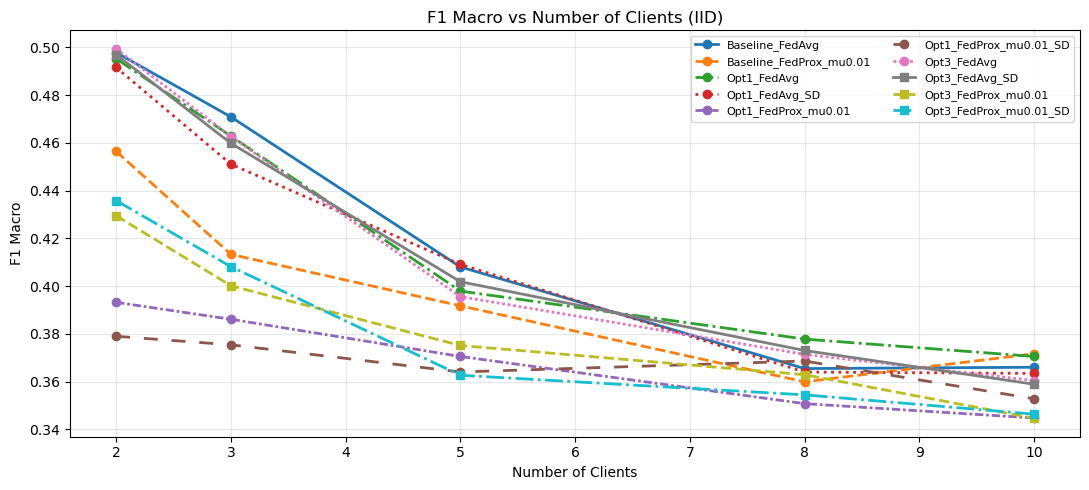

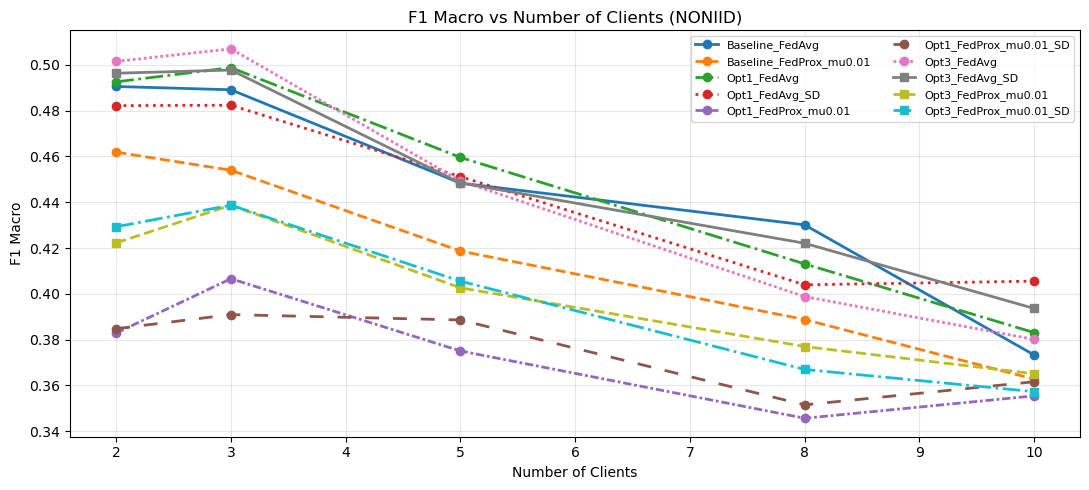

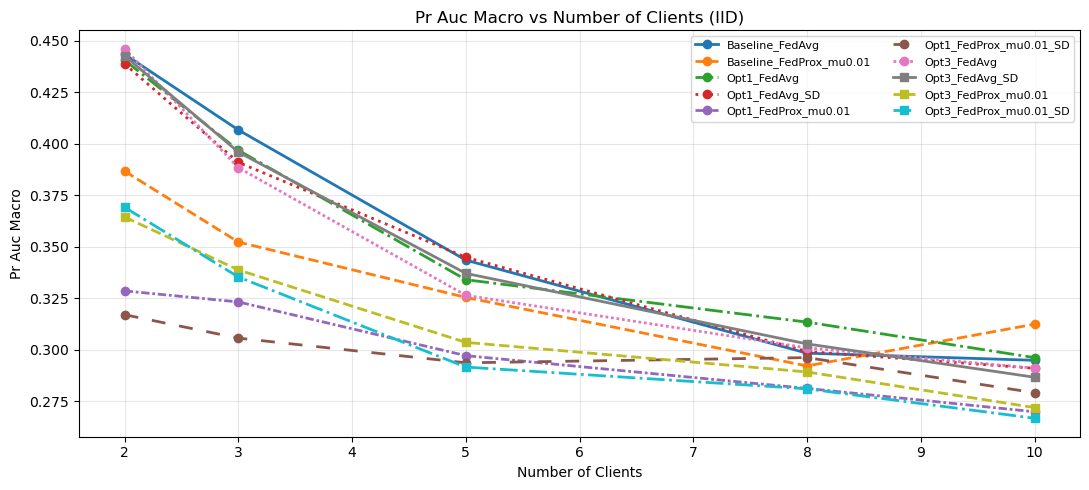

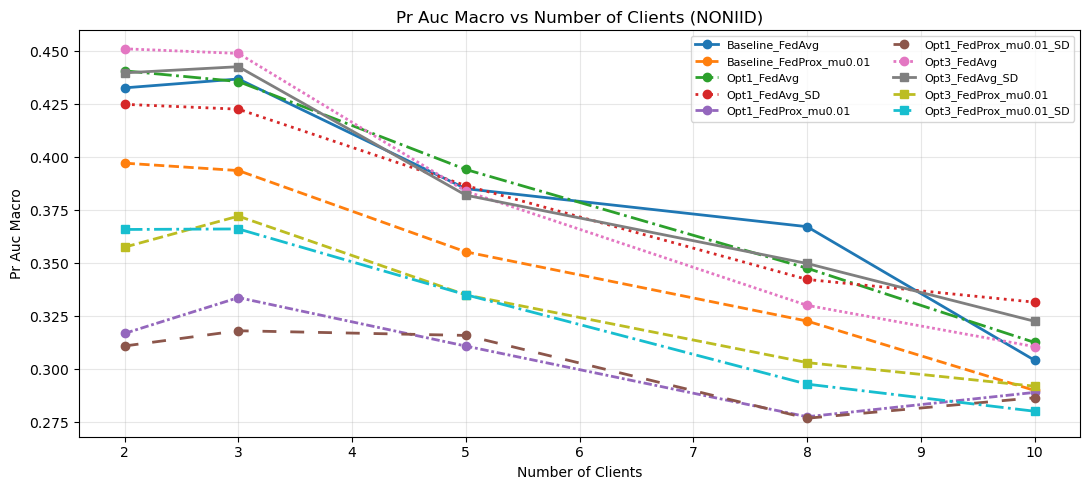

In [50]:
# Plot Macro F1 and PR-AUC Macro

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="f1_macro", bw=False)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="f1_macro", bw=False)

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="pr_auc_macro", bw=False)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="pr_auc_macro", bw=False)

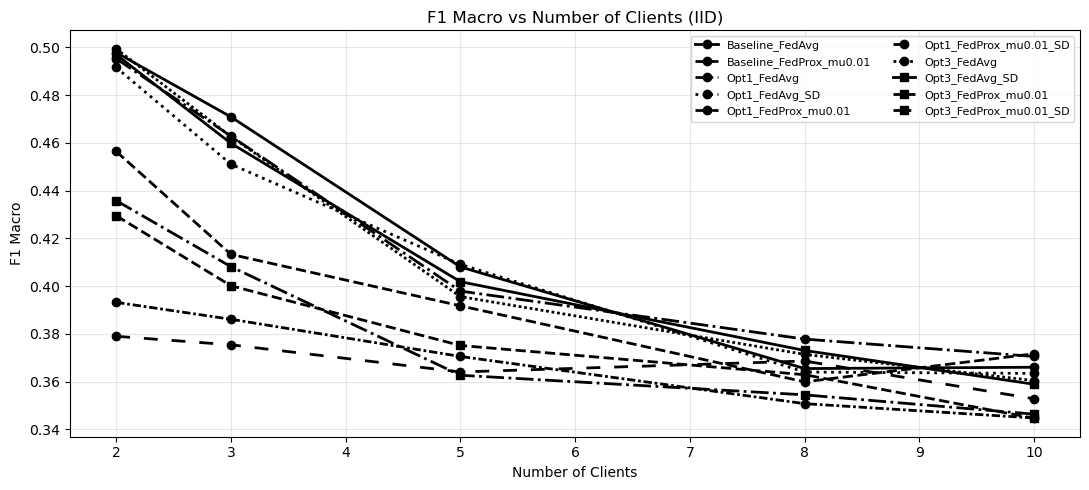

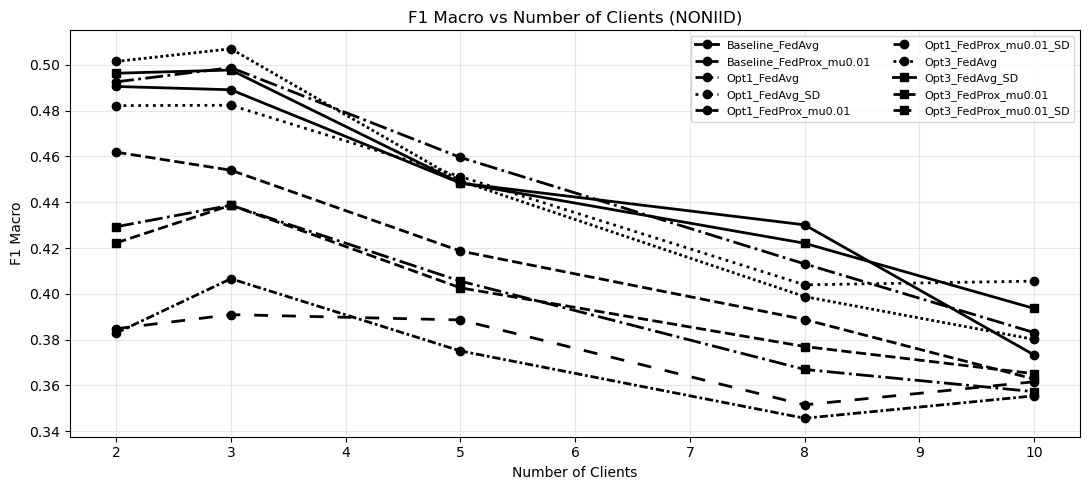

In [51]:
# Black-and-white versions for paper drafting

plot_metric_all_methods(kd_sweep_df, split_mode="iid", metric="f1_macro", bw=True)
plot_metric_all_methods(kd_sweep_df, split_mode="noniid", metric="f1_macro", bw=True)

## Targeted Tuning Plan: Option 3 + FedAvg + Non-IID

This section performs a focused two-phase tuning study on the strongest KD setting observed so far:

- **Method:** Option 3
- **Base algorithm:** FedAvg
- **Split:** non-IID

### Phase 1
Tune the core local KD parameters:
- `kd_alpha`
- `kd_temperature`

### Phase 2
Fix the best Phase 1 setting, then tune server-side distillation:
- `server_distill_steps`
- `server_distill_lr`

This targeted approach is more efficient than tuning all methods and settings jointly,
and aligns with the current evidence that Option 3 under non-IID is the most promising configuration.

### Phase 1: Tune plain Option 3 + FedAvg + non-IID

In [ ]:
# Phase 1: tune Option 3 + FedAvg + non-IID over kd_alpha x kd_temperature

phase1_client_counts = [3, 10]   # one moderate, one harder fragmentation setting

phase1_alpha_grid = [0.3, 0.5, 0.7]
phase1_temp_grid = [1.0, 2.0, 4.0]

phase1_config = config.copy()
phase1_config["rounds"] = 10   # increase later if needed

phase1_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

#phase1_out_path = "../History/opt3_fedavg_noniid_phase1_tuning.csv"
phase1_out_path = os.path.join(KD_HISTORY_DIR, "opt3_phase1_tuning_r10_e1.csv")

In [ ]:
# Phase 1 sweep runner with resume support

if os.path.exists(phase1_out_path):
    phase1_existing = pd.read_csv(phase1_out_path)
    phase1_rows = phase1_existing.to_dict(orient="records")
    phase1_completed = set(
        zip(
            phase1_existing["clients"],
            phase1_existing["kd_alpha"],
            phase1_existing["kd_temperature"]
        )
    )
    print(f"Found existing Phase 1 results at {phase1_out_path}")
    print(f"Loaded {len(phase1_existing)} completed rows.")
else:
    phase1_rows = []
    phase1_completed = set()
    print("No existing Phase 1 results found. Starting fresh.")

for k in phase1_client_counts:
    for alpha in phase1_alpha_grid:
        for temp in phase1_temp_grid:
            run_key = (k, alpha, temp)

            if run_key in phase1_completed:
                print(f"Skipping completed Phase 1 run: K={k} | alpha={alpha} | T={temp}")
                continue

            print(f"\n=== Phase 1 | Opt3 FedAvg NONIID | K={k} | alpha={alpha} | T={temp} ===")

            try:
                phase1_kd_config = copy.deepcopy(kd_config)
                phase1_kd_config["kd_alpha"] = alpha
                phase1_kd_config["kd_temperature"] = temp

                metrics, elapsed = run_fl_kd_once(
                    split_mode="noniid",
                    num_clients=k,
                    local_epochs=1,
                    config=phase1_config,
                    kd_config=phase1_kd_config,
                    train_dataset=train_dataset,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=device,
                    seed=42,
                    method="option3",
                    base_algo="FedAvg",
                    mu=0.0,
                    server_distill=False,
                    **phase1_noniid_params
                )

                row = {
                    "phase": 1,
                    "split": "noniid",
                    "clients": k,
                    "method_name": "Opt3_FedAvg",
                    "method": "option3",
                    "base_algo": "FedAvg",
                    "server_distill": False,
                    "mu": 0.0,

                    "local_epochs": 1,
                    "rounds": phase1_config["rounds"],

                    "kd_alpha": alpha,
                    "kd_temperature": temp,
                    "teacher_steps_per_batch": phase1_kd_config.get("teacher_steps_per_batch", 1),

                    "server_distill_steps": None,
                    "server_distill_lr": None,

                    "f1_macro": metrics.get("f1_macro"),
                    "f1_micro": metrics.get("f1_micro"),
                    "pr_auc_macro": metrics.get("pr_auc_macro"),
                    "pr_auc_micro": metrics.get("pr_auc_micro"),
                    "auc_macro": metrics.get("auc_macro"),
                    "auc_micro": metrics.get("auc_micro"),
                    "best_f1_micro": metrics.get("best_f1_micro"),
                    "best_thr": metrics.get("best_thr"),
                    "time_sec": elapsed,

                    "size_alpha": phase1_noniid_params["size_alpha"],
                    "labels_per_client": phase1_noniid_params["labels_per_client"],
                    "bias_strength": phase1_noniid_params["bias_strength"],
                }

                phase1_rows.append(row)
                phase1_completed.add(run_key)

                pd.DataFrame(phase1_rows).to_csv(phase1_out_path, index=False)
                print(f"Saved Phase 1 result to {phase1_out_path}")

            except Exception as e:
                print(f"FAILED Phase 1: K={k} | alpha={alpha} | T={temp}")
                print(f"Reason: {e}")

print(f"\nPhase 1 finished. Results saved to: {phase1_out_path}")

phase1_df = pd.DataFrame(phase1_rows)
display(phase1_df.head())

In [ ]:
# Load Phase 1 results

phase1_df = pd.read_csv(phase1_out_path)
print("Loaded:", phase1_out_path, "rows=", len(phase1_df))
display(phase1_df.head())

In [ ]:
# Phase 1 summary tables

phase1_summary = phase1_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase1_summary)

phase1_pivot = phase1_df.pivot_table(
    index=["clients", "kd_alpha"],
    columns="kd_temperature",
    values="f1_macro"
)

display(phase1_pivot)

In [ ]:
# Best Phase 1 setting per client count

phase1_best_per_k = (
    phase1_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase1_best_per_k)

In [ ]:
# Choose one global best Phase 1 setting across the tested client counts
# Preference order: mean F1_macro, then mean PR-AUC_macro, then mean AUC_macro

phase1_global_summary = (
    phase1_df.groupby(["kd_alpha", "kd_temperature"], as_index=False)
    .agg({
        "f1_macro": "mean",
        "pr_auc_macro": "mean",
        "auc_macro": "mean",
        "time_sec": "mean"
    })
    .sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(phase1_global_summary)

best_phase1_alpha = float(phase1_global_summary.loc[0, "kd_alpha"])
best_phase1_temp = float(phase1_global_summary.loc[0, "kd_temperature"])

print(f"Best Phase 1 global setting: kd_alpha={best_phase1_alpha}, kd_temperature={best_phase1_temp}")

In [ ]:
# Phase 1 plotting helper

def plot_phase1_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    temps = sorted(d["kd_temperature"].unique())

    plt.figure(figsize=(8, 5))
    for temp in temps:
        g = d[d["kd_temperature"] == temp].sort_values("kd_alpha")
        plt.plot(
            g["kd_alpha"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"T={temp}"
        )

    plt.xlabel("KD Alpha")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Phase 1: {metric.replace('_', ' ').title()} | Opt3 FedAvg NONIID | K={clients_value}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase1_metric(phase1_df, clients_value=3, metric="f1_macro")
plot_phase1_metric(phase1_df, clients_value=10, metric="f1_macro")

plot_phase1_metric(phase1_df, clients_value=3, metric="pr_auc_macro")
plot_phase1_metric(phase1_df, clients_value=10, metric="pr_auc_macro")

### Phase 2: Server Distillation Tuning

Using the best Phase 1 Option 3 setting, this phase tunes:
- `server_distill_steps`
- `server_distill_lr`

The goal is to determine whether server-side refinement can improve the strongest local KD setup.

In [ ]:
# Phase 2: tune server distillation on top of best Phase 1 setting

phase2_client_counts = [3, 10]

phase2_steps_grid = [5, 10, 20]
phase2_lr_grid = [0.001, 0.002, 0.005]

phase2_config = config.copy()
phase2_config["rounds"] = 10

phase2_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85
)

#phase2_out_path = "../History/opt3_fedavg_noniid_phase2_serverdistill_tuning.csv"
phase2_out_path = os.path.join(KD_HISTORY_DIR, "opt3_phase2_serverdistill_tuning_r10_e1.csv")

In [ ]:
# Phase 2 sweep runner with resume support

if os.path.exists(phase2_out_path):
    phase2_existing = pd.read_csv(phase2_out_path)
    phase2_rows = phase2_existing.to_dict(orient="records")
    phase2_completed = set(
        zip(
            phase2_existing["clients"],
            phase2_existing["server_distill_steps"],
            phase2_existing["server_distill_lr"]
        )
    )
    print(f"Found existing Phase 2 results at {phase2_out_path}")
    print(f"Loaded {len(phase2_existing)} completed rows.")
else:
    phase2_rows = []
    phase2_completed = set()
    print("No existing Phase 2 results found. Starting fresh.")

for k in phase2_client_counts:
    for sd_steps in phase2_steps_grid:
        for sd_lr in phase2_lr_grid:
            run_key = (k, sd_steps, sd_lr)

            if run_key in phase2_completed:
                print(f"Skipping completed Phase 2 run: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
                continue

            print(
                f"\n=== Phase 2 | Opt3 FedAvg NONIID + SD | "
                f"K={k} | alpha={best_phase1_alpha} | T={best_phase1_temp} | "
                f"SD_steps={sd_steps} | SD_lr={sd_lr} ==="
            )

            try:
                phase2_kd_config = copy.deepcopy(kd_config)
                phase2_kd_config["kd_alpha"] = best_phase1_alpha
                phase2_kd_config["kd_temperature"] = best_phase1_temp
                phase2_kd_config["server_distill_steps"] = sd_steps
                phase2_kd_config["server_distill_lr"] = sd_lr

                metrics, elapsed = run_fl_kd_once(
                    split_mode="noniid",
                    num_clients=k,
                    local_epochs=1,
                    config=phase2_config,
                    kd_config=phase2_kd_config,
                    train_dataset=train_dataset,
                    val_loader=val_loader,
                    test_loader=test_loader,
                    device=device,
                    seed=42,
                    method="option3",
                    base_algo="FedAvg",
                    mu=0.0,
                    server_distill=True,
                    **phase2_noniid_params
                )

                row = {
                    "phase": 2,
                    "split": "noniid",
                    "clients": k,
                    "method_name": "Opt3_FedAvg_SD",
                    "method": "option3",
                    "base_algo": "FedAvg",
                    "server_distill": True,
                    "mu": 0.0,

                    "local_epochs": 1,
                    "rounds": phase2_config["rounds"],

                    "kd_alpha": best_phase1_alpha,
                    "kd_temperature": best_phase1_temp,
                    "teacher_steps_per_batch": phase2_kd_config.get("teacher_steps_per_batch", 1),

                    "server_distill_steps": sd_steps,
                    "server_distill_lr": sd_lr,

                    "f1_macro": metrics.get("f1_macro"),
                    "f1_micro": metrics.get("f1_micro"),
                    "pr_auc_macro": metrics.get("pr_auc_macro"),
                    "pr_auc_micro": metrics.get("pr_auc_micro"),
                    "auc_macro": metrics.get("auc_macro"),
                    "auc_micro": metrics.get("auc_micro"),
                    "best_f1_micro": metrics.get("best_f1_micro"),
                    "best_thr": metrics.get("best_thr"),
                    "time_sec": elapsed,

                    "size_alpha": phase2_noniid_params["size_alpha"],
                    "labels_per_client": phase2_noniid_params["labels_per_client"],
                    "bias_strength": phase2_noniid_params["bias_strength"],
                }

                phase2_rows.append(row)
                phase2_completed.add(run_key)

                pd.DataFrame(phase2_rows).to_csv(phase2_out_path, index=False)
                print(f"Saved Phase 2 result to {phase2_out_path}")

            except Exception as e:
                print(f"FAILED Phase 2: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
                print(f"Reason: {e}")

print(f"\nPhase 2 finished. Results saved to: {phase2_out_path}")

phase2_df = pd.DataFrame(phase2_rows)
display(phase2_df.head())

In [ ]:
# Load Phase 2 results

phase2_df = pd.read_csv(phase2_out_path)
print("Loaded:", phase2_out_path, "rows=", len(phase2_df))
display(phase2_df.head())

In [ ]:
# Phase 2 summary tables

phase2_summary = phase2_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase2_summary)

phase2_pivot = phase2_df.pivot_table(
    index=["clients", "server_distill_steps"],
    columns="server_distill_lr",
    values="f1_macro"
)

display(phase2_pivot)

In [ ]:
# Best Phase 2 setting per client count

phase2_best_per_k = (
    phase2_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase2_best_per_k)

In [ ]:
# Compare best Phase 2 SD settings against best non-SD Phase 1 setting

phase1_best_compare = phase1_best_per_k[[
    "clients", "kd_alpha", "kd_temperature",
    "f1_macro", "pr_auc_macro", "auc_macro", "time_sec"
]].copy()
phase1_best_compare["variant"] = "Opt3_FedAvg_Best_Phase1"

phase2_best_compare = phase2_best_per_k[[
    "clients", "server_distill_steps", "server_distill_lr",
    "f1_macro", "pr_auc_macro", "auc_macro", "time_sec"
]].copy()
phase2_best_compare["variant"] = "Opt3_FedAvg_SD_Best_Phase2"

display(phase1_best_compare)
display(phase2_best_compare)

In [ ]:
# Phase 2 plotting helper

def plot_phase2_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    lrs = sorted(d["server_distill_lr"].unique())

    plt.figure(figsize=(8, 5))
    for sd_lr in lrs:
        g = d[d["server_distill_lr"] == sd_lr].sort_values("server_distill_steps")
        plt.plot(
            g["server_distill_steps"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"SD LR={sd_lr}"
        )

    plt.xlabel("Server Distill Steps")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(
        f"Phase 2: {metric.replace('_', ' ').title()} | "
        f"Opt3 FedAvg NONIID + SD | K={clients_value}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase2_metric(phase2_df, clients_value=3, metric="f1_macro")
plot_phase2_metric(phase2_df, clients_value=10, metric="f1_macro")

plot_phase2_metric(phase2_df, clients_value=3, metric="pr_auc_macro")
plot_phase2_metric(phase2_df, clients_value=10, metric="pr_auc_macro")

In [ ]:
# Final combined comparison: best non-SD vs best SD settings

final_compare = []

for k in sorted(set(phase1_best_per_k["clients"]).intersection(set(phase2_best_per_k["clients"]))):
    p1 = phase1_best_per_k[phase1_best_per_k["clients"] == k].iloc[0]
    p2 = phase2_best_per_k[phase2_best_per_k["clients"] == k].iloc[0]

    final_compare.append({
        "clients": k,

        "best_phase1_alpha": p1["kd_alpha"],
        "best_phase1_temp": p1["kd_temperature"],
        "phase1_f1_macro": p1["f1_macro"],
        "phase1_pr_auc_macro": p1["pr_auc_macro"],
        "phase1_auc_macro": p1["auc_macro"],

        "best_phase2_sd_steps": p2["server_distill_steps"],
        "best_phase2_sd_lr": p2["server_distill_lr"],
        "phase2_f1_macro": p2["f1_macro"],
        "phase2_pr_auc_macro": p2["pr_auc_macro"],
        "phase2_auc_macro": p2["auc_macro"],

        "delta_f1_macro": p2["f1_macro"] - p1["f1_macro"],
        "delta_pr_auc_macro": p2["pr_auc_macro"] - p1["pr_auc_macro"],
        "delta_auc_macro": p2["auc_macro"] - p1["auc_macro"],
    })

final_compare_df = pd.DataFrame(final_compare)
display(final_compare_df)